In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import yfinance as yf

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU:", device)
else:
    device = torch.device("cpu")
    print("MPS unavailable. Using CPU.")

Using Apple GPU: mps


In [3]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171761,24.638260,23.734002,24.627205,212818400
2015-01-05,23.490803,24.021419,23.305088,23.941826,257142000
2015-01-06,23.493017,23.751692,23.132640,23.554922,263188400
2015-01-07,23.822439,23.921929,23.590294,23.700839,160423600
2015-01-08,24.737745,24.795229,24.032468,24.149647,237458000


In [4]:
print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (2766, 5)

Columns:
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [5]:
close_prices = data[["Close"]].values

print("Number of observations:", len(close_prices))
print(close_prices[:5])

Number of observations: 2766
[[24.17176056]
 [23.49080276]
 [23.4930172 ]
 [23.82243919]
 [24.73774529]]


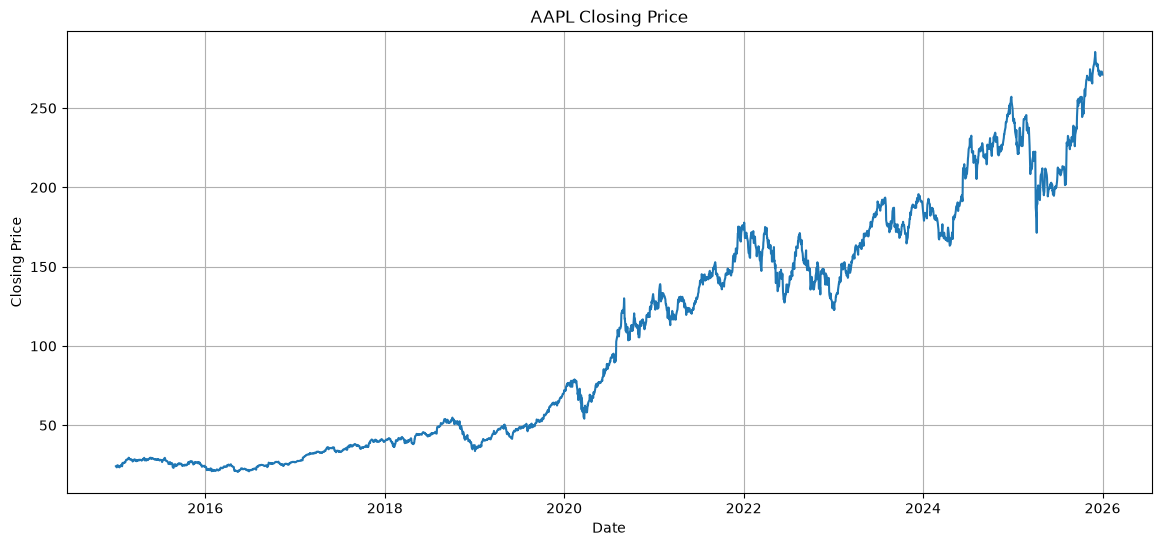

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(data.index, close_prices)

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_prices = scaler.fit_transform(close_prices)

print(scaled_prices[:5])

[[0.013681  ]
 [0.01111004]
 [0.0111184 ]
 [0.01236213]
 [0.01581788]]


In [8]:
train_size = int(len(scaled_prices) * 0.8)

train_data = scaled_prices[:train_size]
test_data = scaled_prices[train_size:]

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 2212
Testing samples: 554


In [9]:
sequence_length = 60

def create_sequences(data, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [10]:
X_train, y_train = create_sequences(
    train_data,
    sequence_length
)

X_test, y_test = create_sequences(
    test_data,
    sequence_length
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2152, 60, 1)
y_train shape: (2152, 1)
X_test shape: (494, 60, 1)
y_test shape: (494, 1)


In [11]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)
print(y_train.shape)

torch.Size([2152, 60, 1])
torch.Size([2152, 1])


In [12]:
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(
    X_train,
    y_train
)

test_dataset = torch.utils.data.TensorDataset(
    X_test,
    y_test
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [13]:
class RNNModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, hidden = self.rnn(x)

        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [14]:
rnn_model = RNNModel()

rnn_model = rnn_model.to(device)

print(rnn_model)

RNNModel(
  (rnn): RNN(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [15]:
def train_model(model, train_loader, epochs=20, learning_rate=0.001):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    losses = []

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader)

        losses.append(average_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {average_loss:.6f}"
        )

    return losses

In [16]:
rnn_losses = train_model(
    rnn_model,
    train_loader,
    epochs=20
)

Epoch [1/20] Loss: 0.029366
Epoch [2/20] Loss: 0.001038
Epoch [3/20] Loss: 0.000142
Epoch [4/20] Loss: 0.000107
Epoch [5/20] Loss: 0.000103
Epoch [6/20] Loss: 0.000100
Epoch [7/20] Loss: 0.000104
Epoch [8/20] Loss: 0.000110
Epoch [9/20] Loss: 0.000094
Epoch [10/20] Loss: 0.000095
Epoch [11/20] Loss: 0.000096
Epoch [12/20] Loss: 0.000099
Epoch [13/20] Loss: 0.000094
Epoch [14/20] Loss: 0.000091
Epoch [15/20] Loss: 0.000092
Epoch [16/20] Loss: 0.000094
Epoch [17/20] Loss: 0.000091
Epoch [18/20] Loss: 0.000099
Epoch [19/20] Loss: 0.000102
Epoch [20/20] Loss: 0.000115


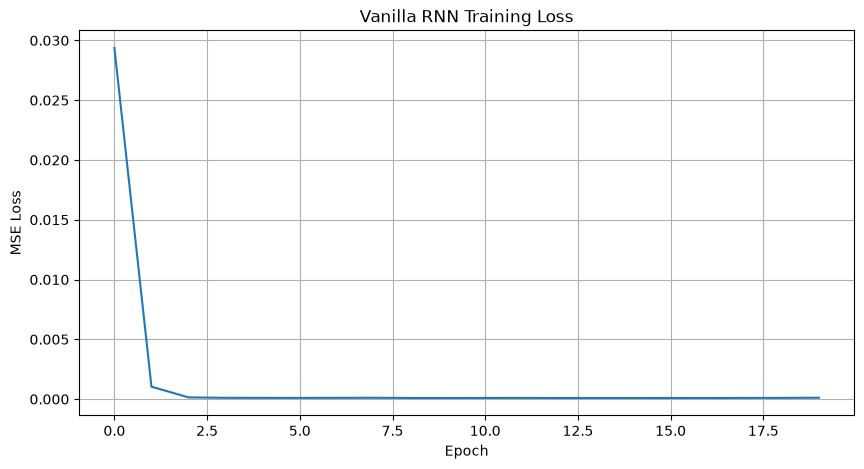

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_losses)

plt.title("Vanilla RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)
plt.show()

In [18]:
def predict_model(model, data_loader):

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            predictions.extend(
                outputs.cpu().numpy()
            )

            actuals.extend(
                y_batch.numpy()
            )

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    return predictions, actuals

In [19]:
rnn_predictions, rnn_actuals = predict_model(
    rnn_model,
    test_loader
)

In [20]:
rnn_predictions_actual = scaler.inverse_transform(
    rnn_predictions
)

rnn_actuals_actual = scaler.inverse_transform(
    rnn_actuals
)

In [21]:
rnn_rmse = np.sqrt(
    mean_squared_error(
        rnn_actuals_actual,
        rnn_predictions_actual
    )
)

rnn_mae = mean_absolute_error(
    rnn_actuals_actual,
    rnn_predictions_actual
)

print("RNN RMSE:", rnn_rmse)
print("RNN MAE:", rnn_mae)

RNN RMSE: 9.62592895780876
RNN MAE: 7.863710403442383


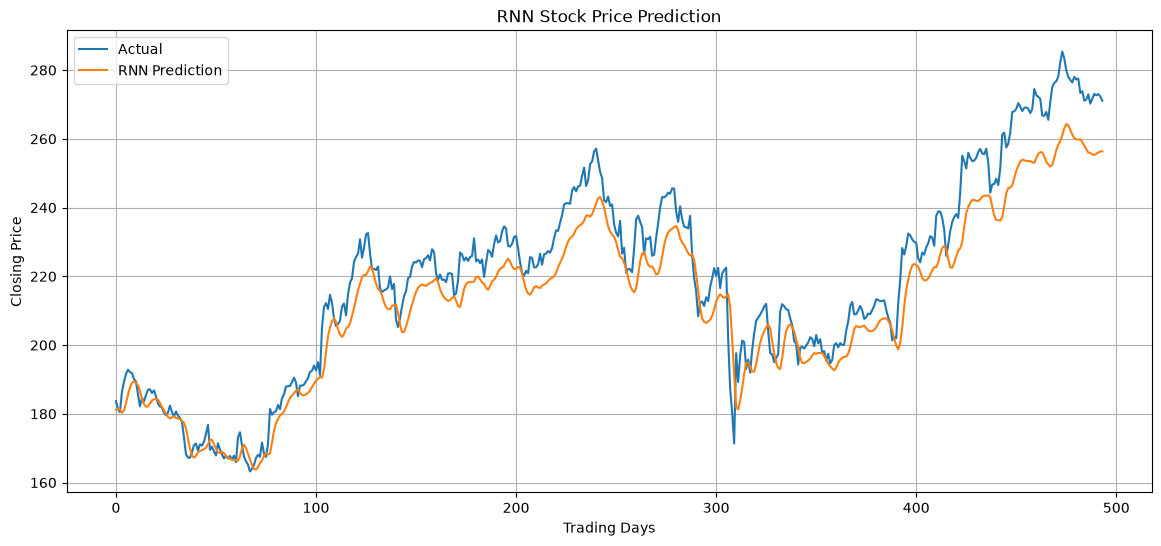

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    rnn_actuals_actual,
    label="Actual"
)

plt.plot(
    rnn_predictions_actual,
    label="RNN Prediction"
)

plt.title("RNN Stock Price Prediction")

plt.xlabel("Trading Days")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [24]:
lstm_model = LSTMModel()

lstm_model = lstm_model.to(device)

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [25]:
lstm_losses = train_model(
    lstm_model,
    train_loader,
    epochs=20
)

Epoch [1/20] Loss: 0.054230
Epoch [2/20] Loss: 0.010291
Epoch [3/20] Loss: 0.001278
Epoch [4/20] Loss: 0.000526
Epoch [5/20] Loss: 0.000311
Epoch [6/20] Loss: 0.000225
Epoch [7/20] Loss: 0.000201
Epoch [8/20] Loss: 0.000195
Epoch [9/20] Loss: 0.000188
Epoch [10/20] Loss: 0.000183
Epoch [11/20] Loss: 0.000201
Epoch [12/20] Loss: 0.000193
Epoch [13/20] Loss: 0.000181
Epoch [14/20] Loss: 0.000178
Epoch [15/20] Loss: 0.000179
Epoch [16/20] Loss: 0.000186
Epoch [17/20] Loss: 0.000178
Epoch [18/20] Loss: 0.000169
Epoch [19/20] Loss: 0.000162
Epoch [20/20] Loss: 0.000174


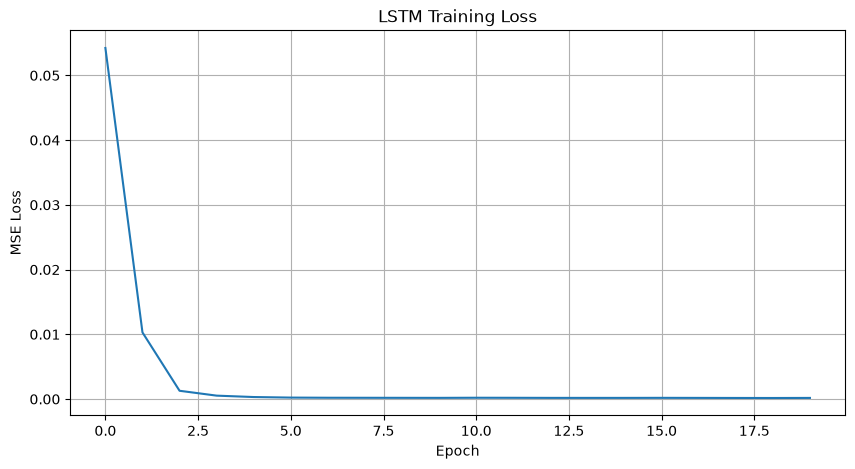

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(lstm_losses)

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)
plt.show()

In [27]:
lstm_predictions, lstm_actuals = predict_model(
    lstm_model,
    test_loader
)

lstm_predictions_actual = scaler.inverse_transform(
    lstm_predictions
)

lstm_actuals_actual = scaler.inverse_transform(
    lstm_actuals
)

In [28]:
lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actuals_actual,
        lstm_predictions_actual
    )
)

lstm_mae = mean_absolute_error(
    lstm_actuals_actual,
    lstm_predictions_actual
)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)

LSTM RMSE: 14.236533779082912
LSTM MAE: 11.995038986206055


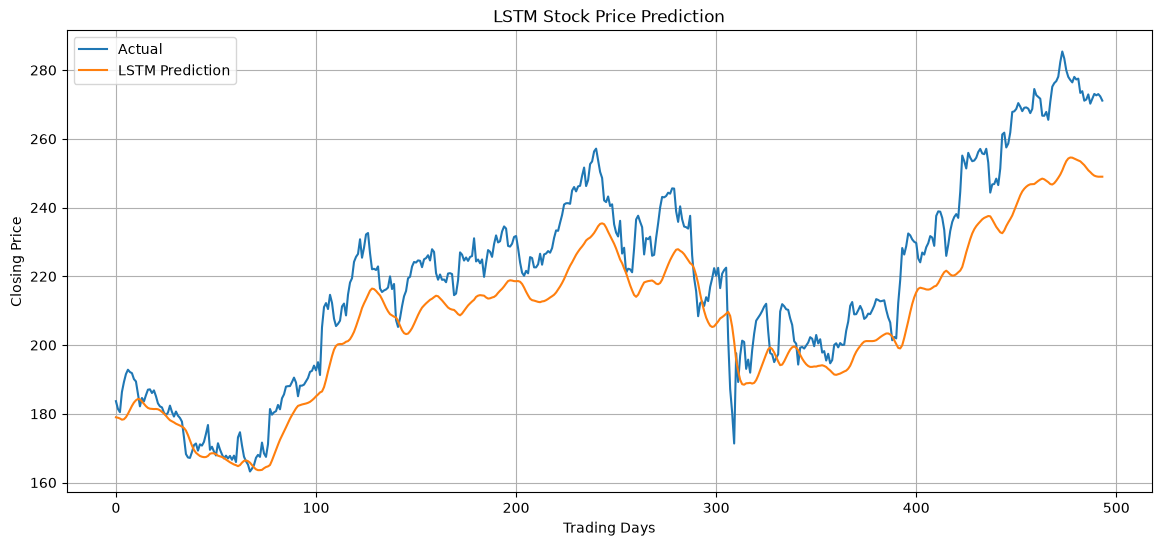

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    lstm_actuals_actual,
    label="Actual"
)

plt.plot(
    lstm_predictions_actual,
    label="LSTM Prediction"
)

plt.title("LSTM Stock Price Prediction")

plt.xlabel("Trading Days")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, hidden = self.gru(x)

        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [31]:
gru_model = GRUModel()

gru_model = gru_model.to(device)

print(gru_model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [32]:
gru_losses = train_model(
    gru_model,
    train_loader,
    epochs=20
)

Epoch [1/20] Loss: 0.018908
Epoch [2/20] Loss: 0.000420
Epoch [3/20] Loss: 0.000153
Epoch [4/20] Loss: 0.000110
Epoch [5/20] Loss: 0.000114
Epoch [6/20] Loss: 0.000092
Epoch [7/20] Loss: 0.000108
Epoch [8/20] Loss: 0.000086
Epoch [9/20] Loss: 0.000090
Epoch [10/20] Loss: 0.000087
Epoch [11/20] Loss: 0.000082
Epoch [12/20] Loss: 0.000087
Epoch [13/20] Loss: 0.000085
Epoch [14/20] Loss: 0.000088
Epoch [15/20] Loss: 0.000078
Epoch [16/20] Loss: 0.000077
Epoch [17/20] Loss: 0.000072
Epoch [18/20] Loss: 0.000075
Epoch [19/20] Loss: 0.000087
Epoch [20/20] Loss: 0.000074


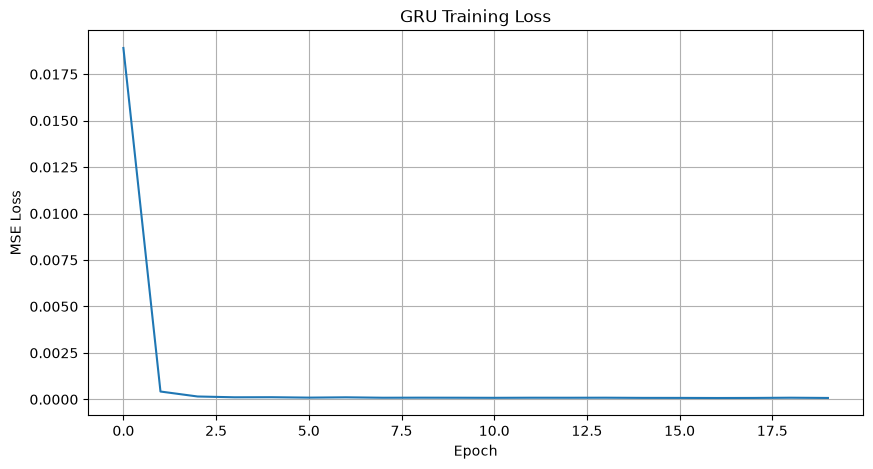

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(gru_losses)

plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)
plt.show()

In [34]:
gru_predictions, gru_actuals = predict_model(
    gru_model,
    test_loader
)

gru_predictions_actual = scaler.inverse_transform(
    gru_predictions
)

gru_actuals_actual = scaler.inverse_transform(
    gru_actuals
)

In [35]:
gru_rmse = np.sqrt(
    mean_squared_error(
        gru_actuals_actual,
        gru_predictions_actual
    )
)

gru_mae = mean_absolute_error(
    gru_actuals_actual,
    gru_predictions_actual
)

print("GRU RMSE:", gru_rmse)
print("GRU MAE:", gru_mae)

GRU RMSE: 4.9695527969658455
GRU MAE: 3.6203935146331787


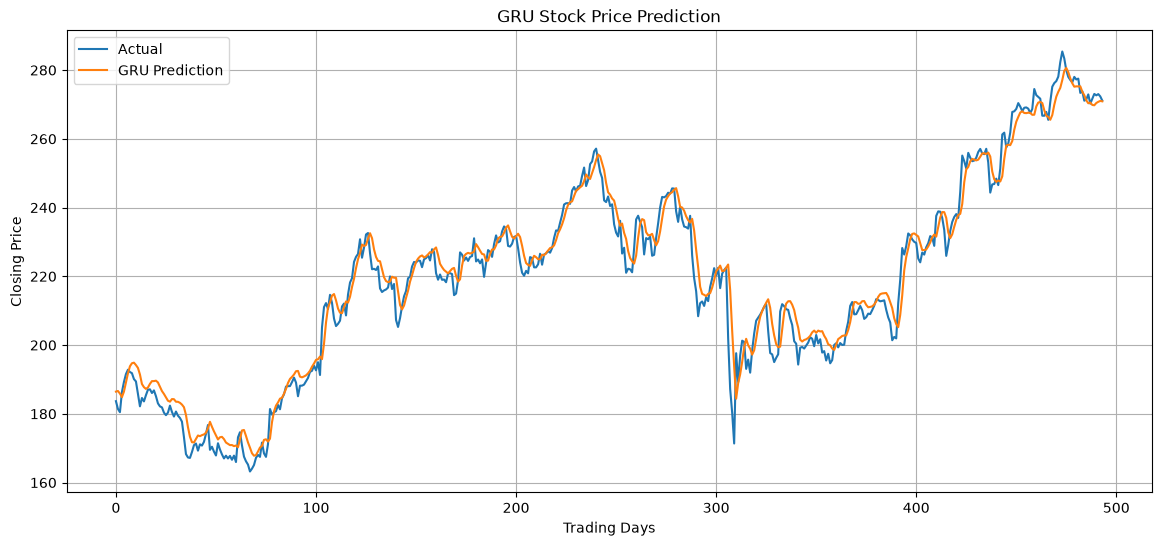

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    gru_actuals_actual,
    label="Actual"
)

plt.plot(
    gru_predictions_actual,
    label="GRU Prediction"
)

plt.title("GRU Stock Price Prediction")

plt.xlabel("Trading Days")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [37]:
results = pd.DataFrame({
    "Model": [
        "Vanilla RNN",
        "LSTM",
        "GRU"
    ],
    
    "RMSE": [
        rnn_rmse,
        lstm_rmse,
        gru_rmse
    ],
    
    "MAE": [
        rnn_mae,
        lstm_mae,
        gru_mae
    ]
})

results

,Model,RMSE,MAE
0,Vanilla RNN,9.625929,7.863710
1,LSTM,14.236534,11.995039
2,GRU,4.969553,3.620394


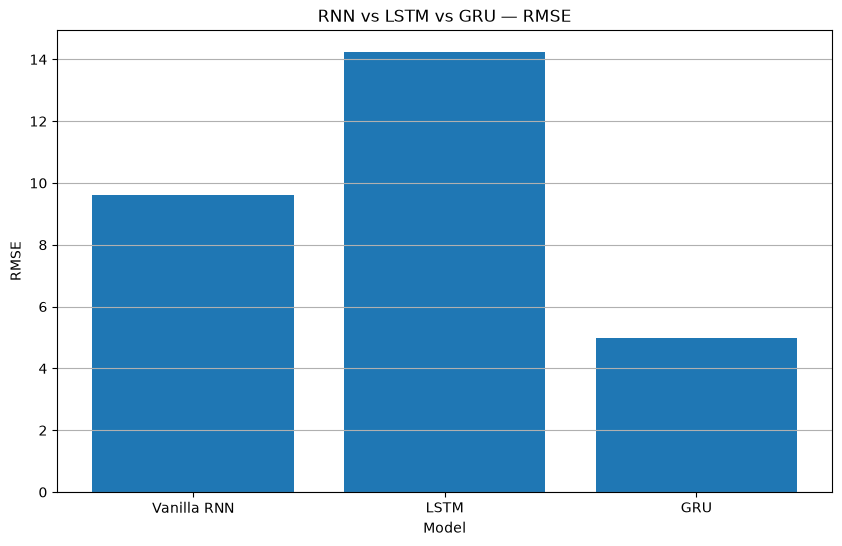

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("RNN vs LSTM vs GRU — RMSE")

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.grid(axis="y")

plt.show()

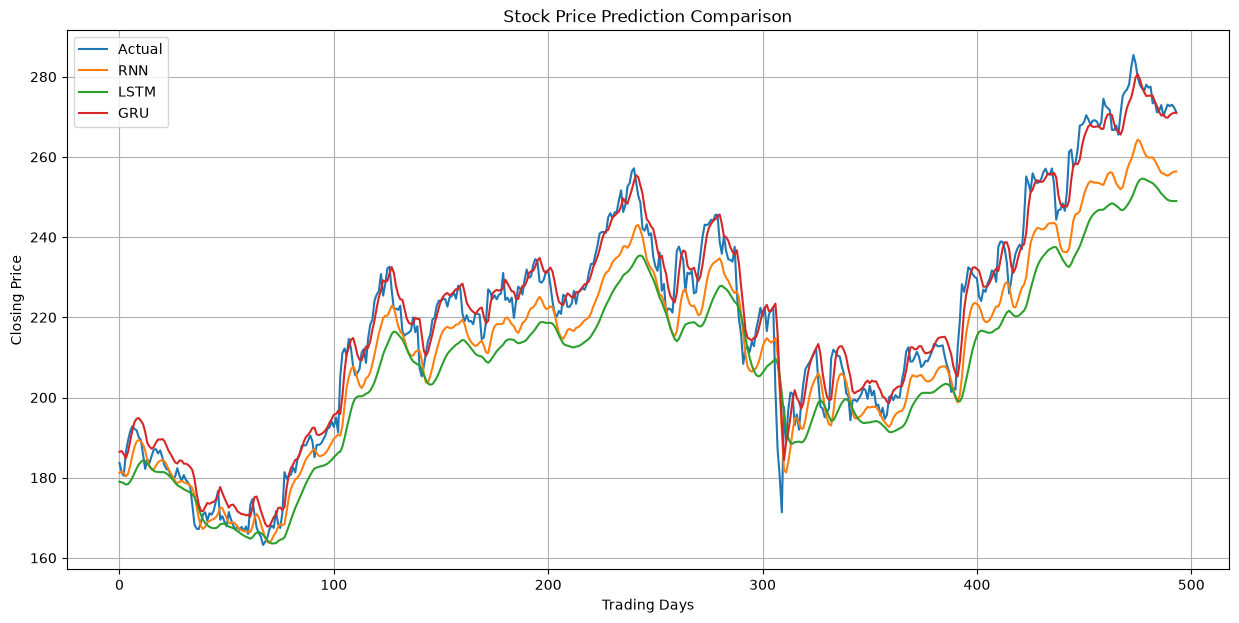

In [39]:
plt.figure(figsize=(15, 7))

plt.plot(
    rnn_actuals_actual,
    label="Actual"
)

plt.plot(
    rnn_predictions_actual,
    label="RNN"
)

plt.plot(
    lstm_predictions_actual,
    label="LSTM"
)

plt.plot(
    gru_predictions_actual,
    label="GRU"
)

plt.title("Stock Price Prediction Comparison")

plt.xlabel("Trading Days")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [40]:
torch.manual_seed(42)

sequence_length_long = 200
num_samples = 2000

X_long = torch.randn(
    num_samples,
    sequence_length_long,
    1
)

y_long = X_long[:, 0, :]

In [41]:
class LongRNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        output, hidden = self.rnn(x)

        return self.fc(output[:, -1, :])

In [42]:
class LongLSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        return self.fc(output[:, -1, :])

In [43]:
long_dataset = torch.utils.data.TensorDataset(
    X_long,
    y_long
)

long_loader = torch.utils.data.DataLoader(
    long_dataset,
    batch_size=64,
    shuffle=True
)

In [44]:
long_rnn = LongRNN().to(device)

long_lstm = LongLSTM().to(device)

In [45]:
def train_long_sequence_model(
    model,
    loader,
    epochs=15
):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        total_loss = 0

        model.train()

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(
                output,
                y_batch
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        losses.append(avg_loss)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Loss: {avg_loss:.6f}"
        )

    return losses

In [46]:
long_rnn_losses = train_long_sequence_model(
    long_rnn,
    long_loader
)

Epoch 1/15 Loss: 1.015046
Epoch 2/15 Loss: 1.004407
Epoch 3/15 Loss: 1.015346
Epoch 4/15 Loss: 1.004449
Epoch 5/15 Loss: 0.998550
Epoch 6/15 Loss: 1.002423
Epoch 7/15 Loss: 0.995011
Epoch 8/15 Loss: 1.004331
Epoch 9/15 Loss: 1.006514
Epoch 10/15 Loss: 1.001750
Epoch 11/15 Loss: 1.003074
Epoch 12/15 Loss: 1.009056
Epoch 13/15 Loss: 0.998666
Epoch 14/15 Loss: 1.013657
Epoch 15/15 Loss: 0.989400


In [47]:
long_lstm_losses = train_long_sequence_model(
    long_lstm,
    long_loader
)

Epoch 1/15 Loss: 0.993861
Epoch 2/15 Loss: 0.999175
Epoch 3/15 Loss: 1.003486
Epoch 4/15 Loss: 1.011944
Epoch 5/15 Loss: 1.006975
Epoch 6/15 Loss: 1.024964
Epoch 7/15 Loss: 1.001759
Epoch 8/15 Loss: 1.004621
Epoch 9/15 Loss: 1.010646
Epoch 10/15 Loss: 1.002550
Epoch 11/15 Loss: 1.019771
Epoch 12/15 Loss: 1.010940
Epoch 13/15 Loss: 1.001315
Epoch 14/15 Loss: 1.000129
Epoch 15/15 Loss: 0.995254


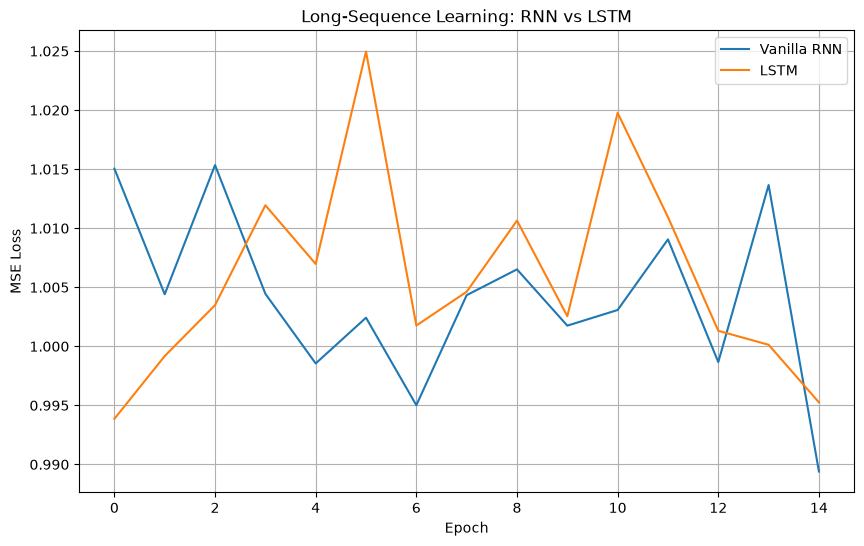

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    long_rnn_losses,
    label="Vanilla RNN"
)

plt.plot(
    long_lstm_losses,
    label="LSTM"
)

plt.title(
    "Long-Sequence Learning: RNN vs LSTM"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
torch.manual_seed(42)

rnn = nn.RNN(
    input_size=1,
    hidden_size=32,
    batch_first=True
).to(device)

x = torch.randn(
    1,
    200,
    1,
    device=device
)

output, hidden = rnn(x)

loss = output[:, -1, :].sum()

loss.backward()

In [50]:
torch.manual_seed(42)

input_size = 1
hidden_size = 16
sequence_length = 100

Wx = torch.randn(
    hidden_size,
    input_size,
    device=device,
    requires_grad=True
)

Wh = torch.randn(
    hidden_size,
    hidden_size,
    device=device,
    requires_grad=True
) * 0.1

b = torch.zeros(
    hidden_size,
    device=device,
    requires_grad=True
)

x = torch.randn(
    sequence_length,
    input_size,
    device=device
)

h = torch.zeros(
    hidden_size,
    device=device
)

hidden_states = []

for t in range(sequence_length):

    h = torch.tanh(
        Wx @ x[t] +
        Wh @ h +
        b
    )

    h.retain_grad()

    hidden_states.append(h)

loss = hidden_states[-1].sum()

loss.backward()

In [51]:
gradient_magnitudes = []

for h in hidden_states:

    if h.grad is not None:

        magnitude = h.grad.norm().item()

    else:

        magnitude = 0

    gradient_magnitudes.append(magnitude)

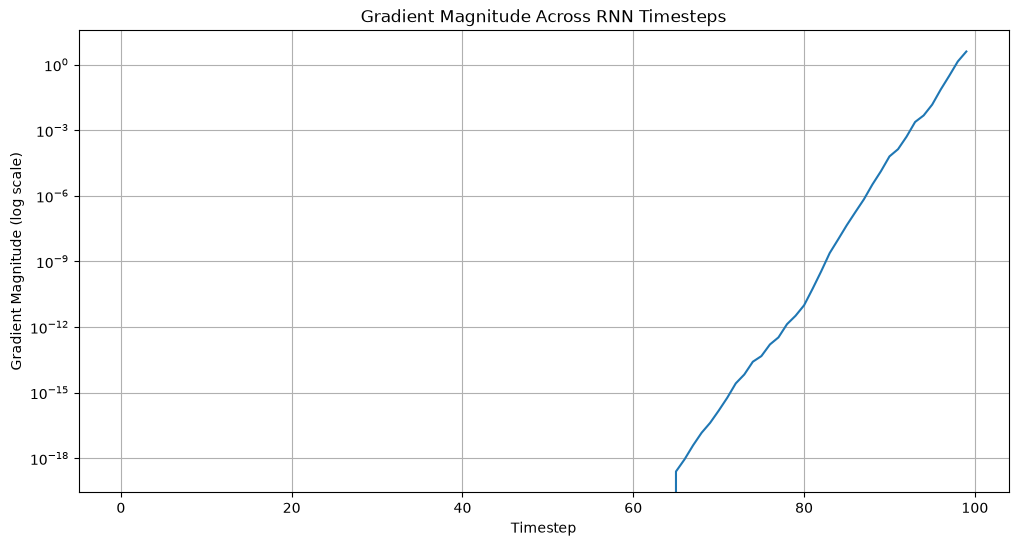

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    gradient_magnitudes
)

plt.yscale("log")

plt.title(
    "Gradient Magnitude Across RNN Timesteps"
)

plt.xlabel("Timestep")
plt.ylabel("Gradient Magnitude (log scale)")

plt.grid(True)

plt.show()

In [53]:
comparison = pd.DataFrame({
    "Architecture": [
        "Vanilla RNN",
        "LSTM",
        "GRU"
    ],

    "Memory": [
        "Short-term",
        "Long-term",
        "Long-term"
    ],

    "Gates": [
        "No",
        "Yes",
        "Yes"
    ],

    "Vanishing Gradient": [
        "High risk",
        "Reduced",
        "Reduced"
    ],

    "Sequential Processing": [
        "Yes",
        "Yes",
        "Yes"
    ]
})

comparison

,Architecture,Memory,Gates,Vanishing Gradient,Sequential Processing
0,Vanilla RNN,Short-term,No,High risk,Yes
1,LSTM,Long-term,Yes,Reduced,Yes
2,GRU,Long-term,Yes,Reduced,Yes


In [54]:
print("========== FINAL RESULTS ==========")

print(f"RNN  RMSE: {rnn_rmse:.4f}")
print(f"RNN  MAE : {rnn_mae:.4f}")

print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM MAE : {lstm_mae:.4f}")

print(f"GRU  RMSE: {gru_rmse:.4f}")
print(f"GRU  MAE : {gru_mae:.4f}")

========== FINAL RESULTS ==========
RNN  RMSE: 9.6259
RNN  MAE : 7.8637
LSTM RMSE: 14.2365
LSTM MAE : 11.9950
GRU  RMSE: 4.9696
GRU  MAE : 3.6204
